# Grubbs Test for a Single Outlier

The **Grubbs test** (also called the extreme studentised deviate test) detects whether a dataset contains a single outlier, assuming the data is approximately normal. The test statistic G is the number of standard deviations between the most extreme value and the mean.

| Property | Value |
|---|---|
| **H₀** | No outlier in the dataset |
| **H₁** | The most extreme value is an outlier |
| **Test statistic** | G = max|xᵢ − x̄| / s |
| **Assumption** | Data approximately Normal |
| **Tests** | Two-sided (most extreme), or one-sided (max or min) |
| **Limitation** | One outlier at a time; use ESD test for multiple outliers |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

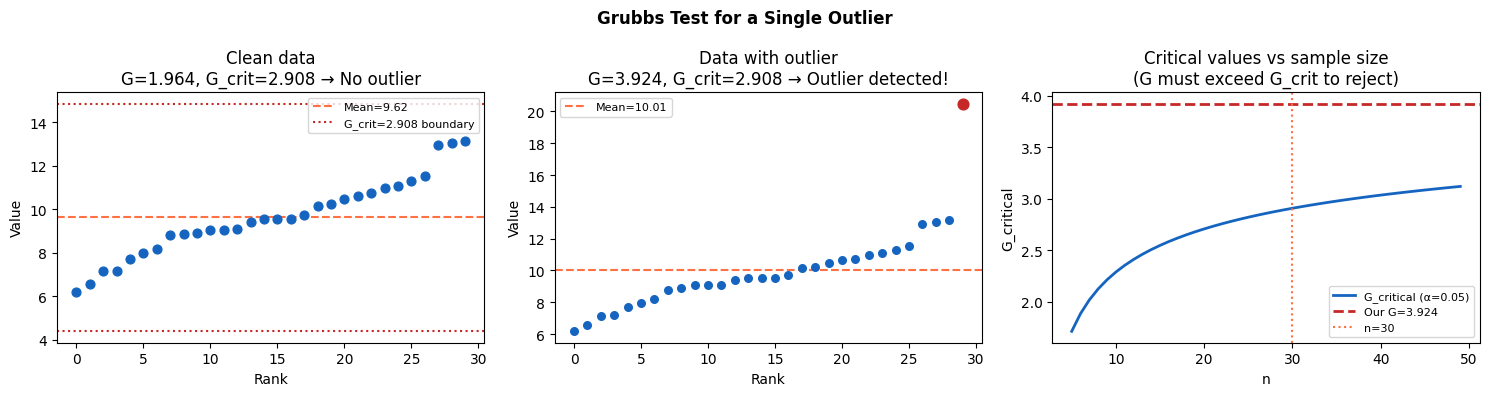

Clean data:    G=1.9637, G_crit=2.9085 → No outlier
Outlier data:  G=3.9241, G_crit=2.9085 → Outlier
Detected outlier value: 20.50


In [2]:
def grubbs_test(data, alpha=0.05):
    n = len(data)
    mean, std = data.mean(), data.std(ddof=1)
    G = np.max(np.abs(data - mean)) / std
    # Critical value from t-distribution
    t_crit = stats.t.ppf(1 - alpha / (2*n), df=n-2)
    G_crit = ((n-1)/np.sqrt(n)) * np.sqrt(t_crit**2 / (n-2 + t_crit**2))
    outlier_idx = np.argmax(np.abs(data - mean))
    p_approx = 1 - (1 - stats.t.sf(G * np.sqrt(n*(n-2)/(n-1-G**2*(n/(n-1)))), df=n-2) * 2*n)
    return G, G_crit, outlier_idx, data[outlier_idx]

np.random.seed(42)
n = 30
data_clean   = np.random.normal(10, 2, n)
data_outlier = data_clean.copy()
data_outlier[15] = 20.5  # inject outlier

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Grubbs Test for a Single Outlier', fontsize=12, fontweight='bold')

# Panel 1: clean data
G1, Gc1, idx1, val1 = grubbs_test(data_clean)
axes[0].scatter(range(n), np.sort(data_clean), color='#1565C0', s=40, zorder=3)
axes[0].axhline(data_clean.mean(), color='#FF7043', lw=1.5, ls='--', label=f'Mean={data_clean.mean():.2f}')
axes[0].axhline(data_clean.mean()+Gc1*data_clean.std(ddof=1), color='#C62828', lw=1.5, ls=':',
                label=f'G_crit={Gc1:.3f} boundary')
axes[0].axhline(data_clean.mean()-Gc1*data_clean.std(ddof=1), color='#C62828', lw=1.5, ls=':')
axes[0].set_title(f'Clean data\nG={G1:.3f}, G_crit={Gc1:.3f} → No outlier')
axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Value')
axes[0].legend(fontsize=8)

# Panel 2: data with outlier
G2, Gc2, idx2, val2 = grubbs_test(data_outlier)
x2 = np.sort(data_outlier)
is_out = x2 == val2
colors2 = ['#C62828' if o else '#1565C0' for o in is_out]
for xi, yi, ci in zip(range(n), x2, colors2):
    axes[1].scatter(xi, yi, color=ci, s=60 if ci=='#C62828' else 30, zorder=3)
axes[1].axhline(data_outlier.mean(), color='#FF7043', lw=1.5, ls='--',
                label=f'Mean={data_outlier.mean():.2f}')
axes[1].set_title(f'Data with outlier\nG={G2:.3f}, G_crit={Gc2:.3f} → Outlier detected!')
axes[1].set_xlabel('Rank'); axes[1].set_ylabel('Value')
axes[1].legend(fontsize=8)

# Panel 3: G-statistic vs sample size critical values
sample_sizes = np.arange(5, 50)
g_crits = []
for ni in sample_sizes:
    t_c = stats.t.ppf(1 - 0.05/(2*ni), df=ni-2)
    g_crits.append(((ni-1)/np.sqrt(ni)) * np.sqrt(t_c**2 / (ni-2 + t_c**2)))
axes[2].plot(sample_sizes, g_crits, color='#1565C0', lw=2, label='G_critical (α=0.05)')
axes[2].axhline(G2, color='#C62828', lw=2, ls='--', label=f'Our G={G2:.3f}')
axes[2].axvline(n, color='#FF7043', lw=1.5, ls=':', label=f'n={n}')
axes[2].set_title('Critical values vs sample size\n(G must exceed G_crit to reject)')
axes[2].set_xlabel('n'); axes[2].set_ylabel('G_critical')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f'Clean data:    G={G1:.4f}, G_crit={Gc1:.4f} → {"Outlier" if G1>Gc1 else "No outlier"}')
print(f'Outlier data:  G={G2:.4f}, G_crit={Gc2:.4f} → {"Outlier" if G2>Gc2 else "No outlier"}')
print(f'Detected outlier value: {val2:.2f}')

## Key Takeaways

| | |
|---|---|
| **G = max|x−x̄|/s** | The most extreme value in standard deviation units from the mean |
| **One at a time** | Test only one outlier; if removed, re-test for another |
| **Masking** | Multiple outliers can mask each other — use ESD test instead |
| **Normal assumption** | Invalid for skewed data; use domain knowledge first |
| **Swamping** | Legitimate outliers can inflate s, reducing G — they mask themselves |
| **Visual first** | Always plot the data before applying the test |